# Step : Import Dependencies

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2 : Data Loading and Understanding

In [4]:
df = pd.read_csv(r"C:\Users\Sufiyan\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
pd.set_option("display.max_columns", None)

In [7]:
df.shape

(7043, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.drop(columns=["customerID"], inplace=True)

In [10]:
for col in df.select_dtypes("object"):
    print(df[col].unique())
    print("-"*50)

['Female' 'Male']
--------------------------------------------------
['Yes' 'No']
--------------------------------------------------
['No' 'Yes']
--------------------------------------------------
['No' 'Yes']
--------------------------------------------------
['No phone service' 'No' 'Yes']
--------------------------------------------------
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
['No' 'Yes' 'No internet service']
--------------------------------------------------
['Yes' 'No' 'No internet service']
--------------------------------------------------
['No' 'Yes' 'No internet service']
--------------------------------------------------
['No' 'Yes' 'No internet service']
--------------------------------------------------
['No' 'Yes' 'No internet service']
--------------------------------------------------
['No' 'Yes' 'No internet service']
--------------------------------------------------
['Month-to-month' 'One year' 'Two year']
---------------------

In [11]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df["TotalCharges"].value_counts()

TotalCharges
20.2      11
          11
19.75      9
19.65      8
19.9       8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
108.15     1
Name: count, Length: 6531, dtype: int64

In [13]:
df[df["TotalCharges"] == " "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [14]:
df["TotalCharges"] = df["TotalCharges"].replace({" " : "0.0"})

In [15]:
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [16]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# Key Insights

* drop customerID Feature
* replace empty space value to 0.0 in TotalCharges Feature
* Analyzed the class Distribution of target column (imbalanced maj:No, min:Yes)
* Change TotalCharges datatype object to float


# Step 3 EDA

In [18]:
def plot_histogram(df, col_name):
    col_mean = df[col_name].mean()
    col_median = df[col_name].median()
    sb.histplot(data=df, x=col_name, kde=True)
    plt.axvline(col_mean, linestyle="-", color="red", label="Mean")
    plt.axvline(col_median, linestyle="--", color="blue", label="Median")
    plt.legend()
    plt.show()

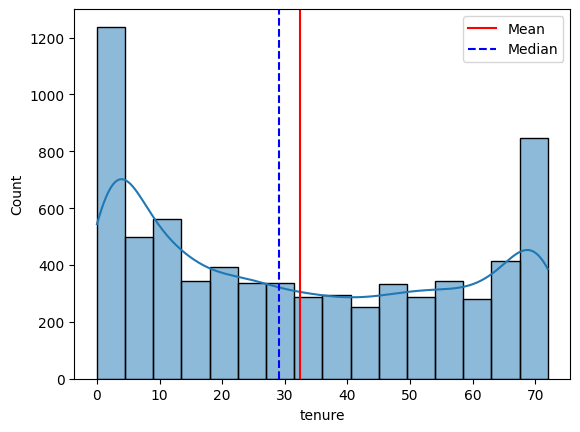

In [19]:
plot_histogram(df, "tenure")

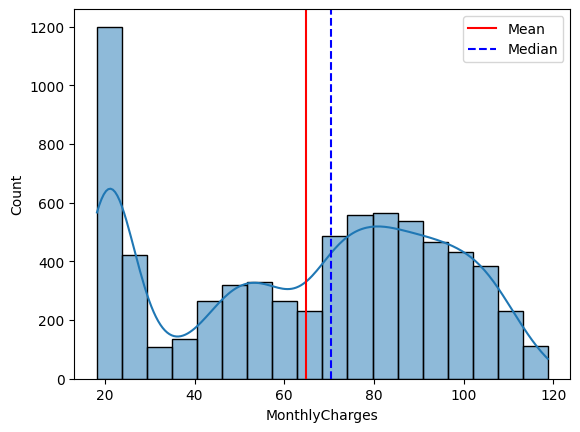

In [20]:
plot_histogram(df, "MonthlyCharges")

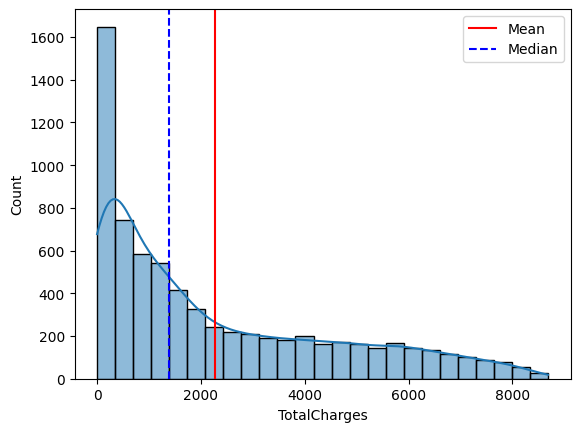

In [21]:
plot_histogram(df, "TotalCharges")

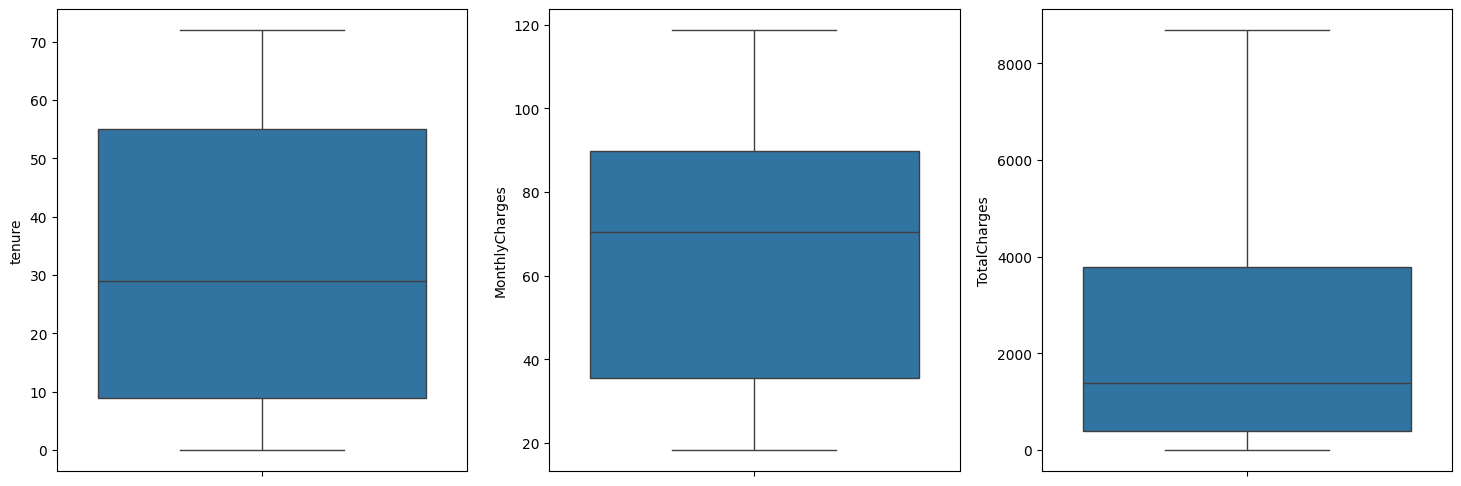

In [38]:
plt.figure(figsize=(18, 6))
plt.subplot(1,3,1)
sb.boxplot(df["tenure"])

plt.subplot(1,3,2)
sb.boxplot(df["MonthlyCharges"])

plt.subplot(1,3,3)
sb.boxplot(df["TotalCharges"])

plt.show()


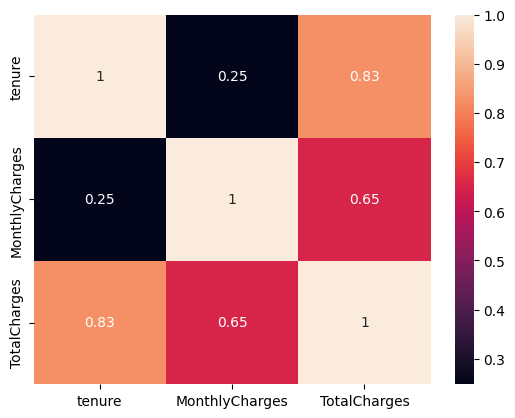

In [39]:
sb.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True)
plt.show()

# Categorical Feature Analysis

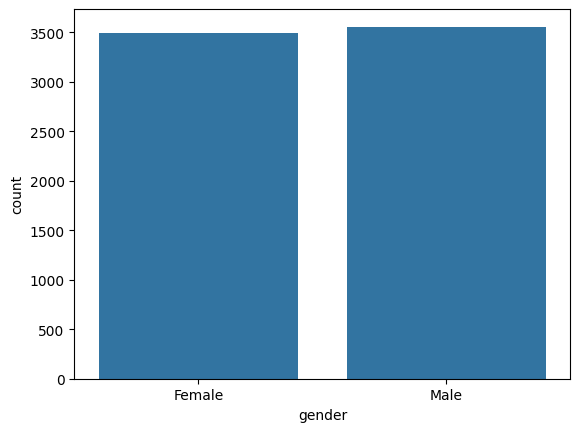

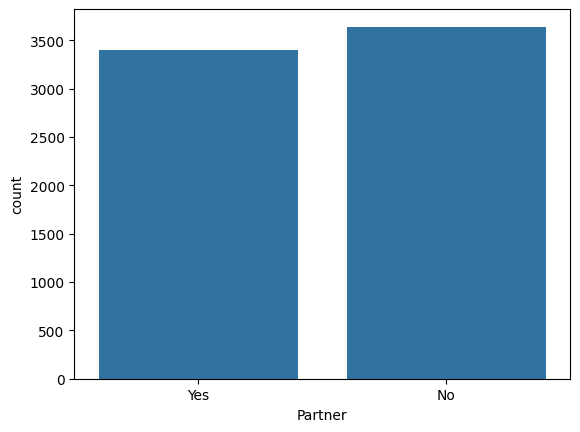

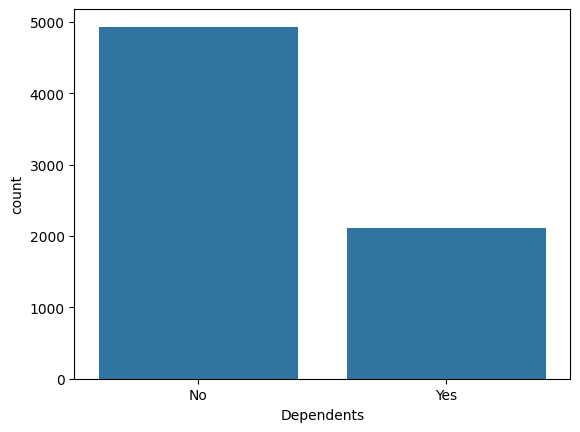

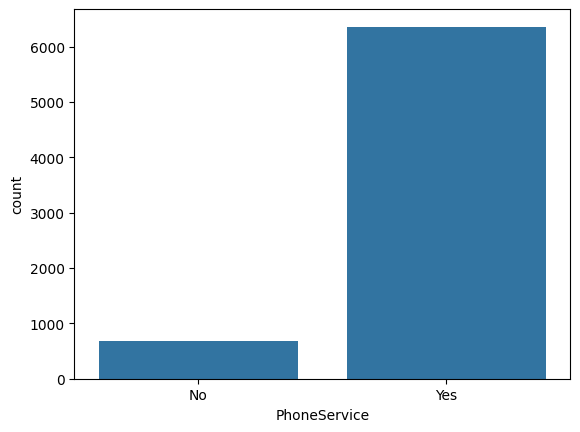

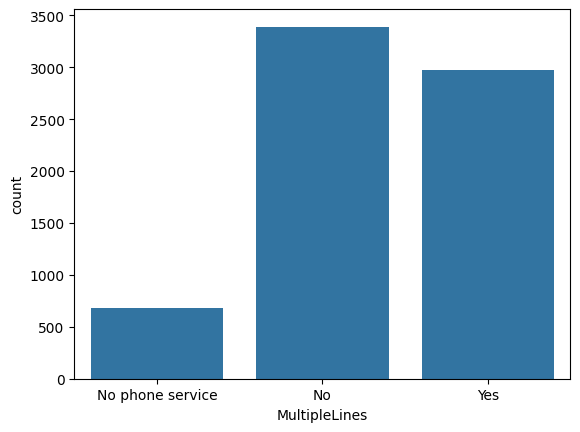

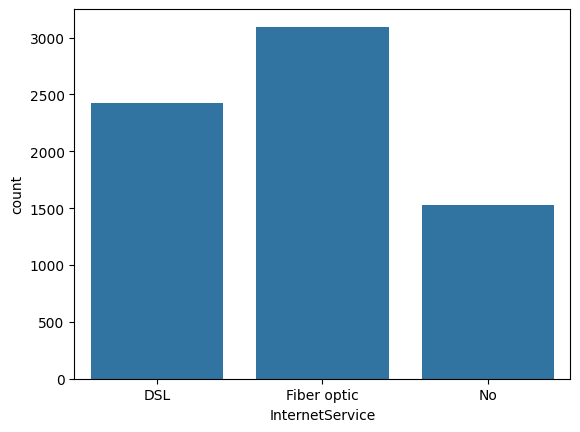

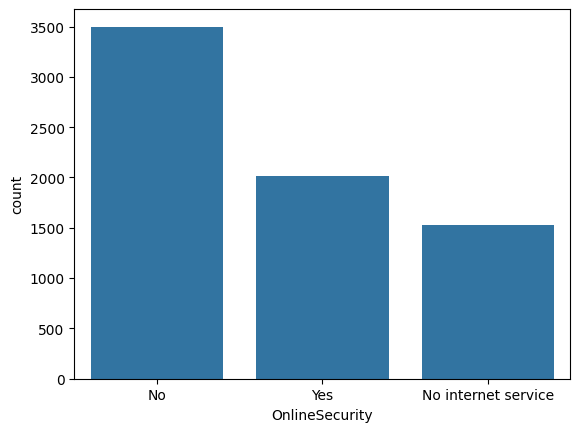

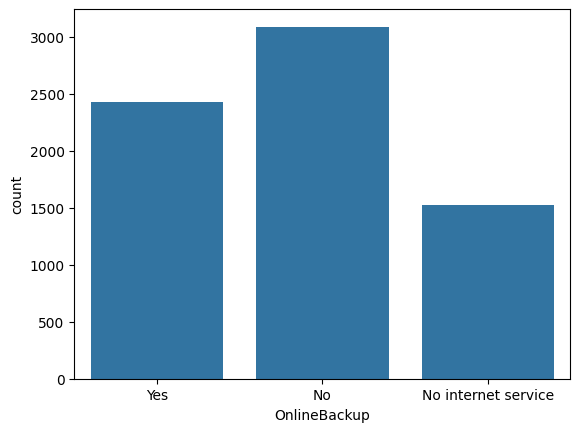

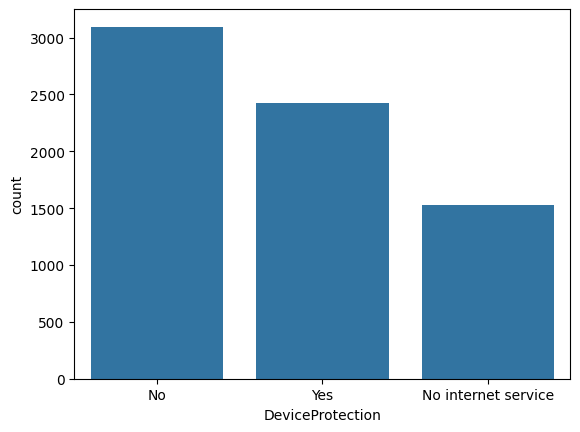

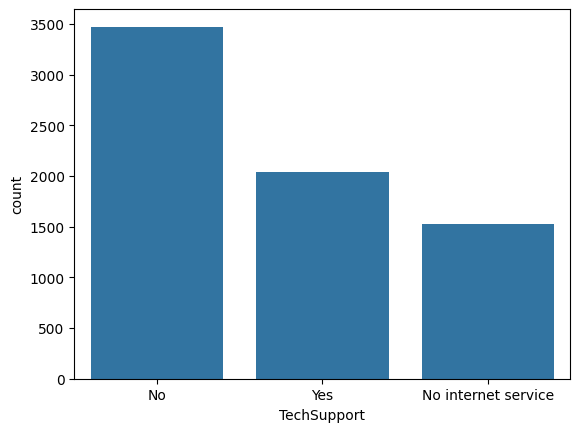

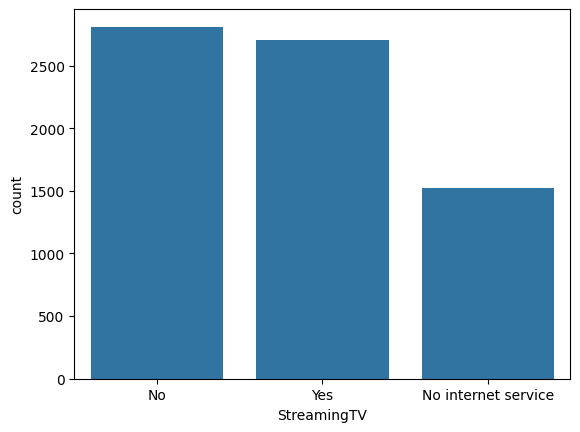

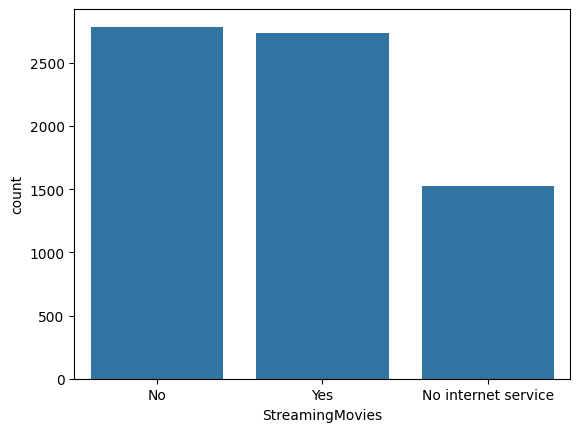

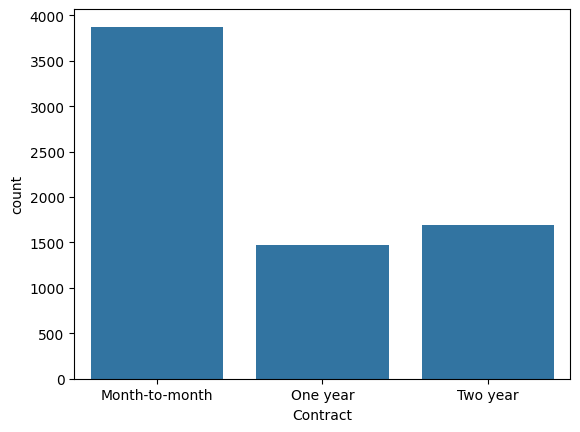

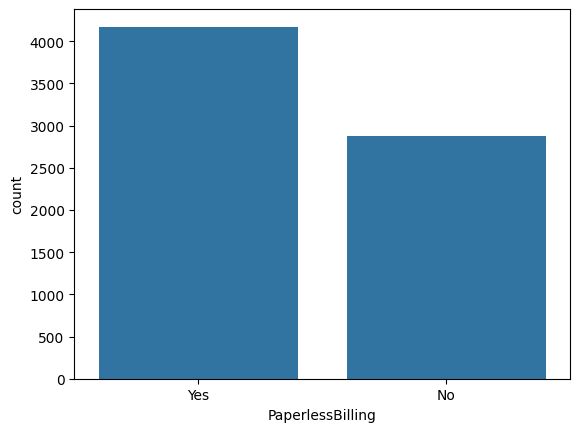

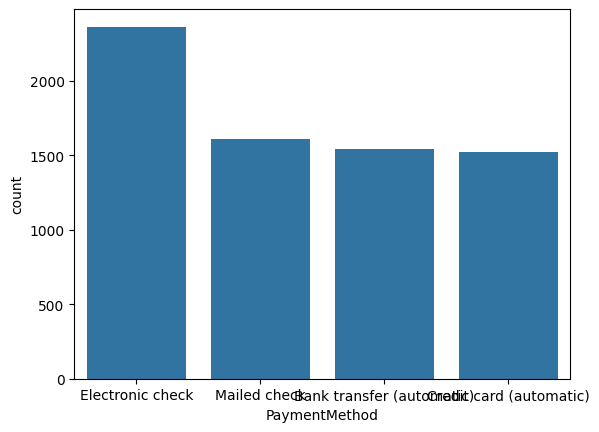

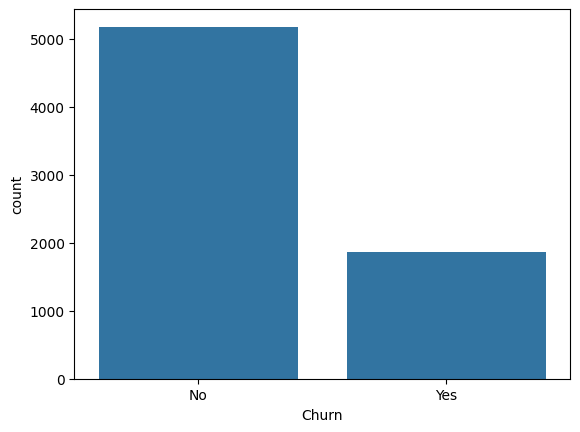

In [41]:
for col in df.select_dtypes("object"):
    sb.countplot(data=df, x=col)
    plt.show()

# Key Insights

* histogram of Numerical Feature

  1. Tenure is bimodally distributed, with most customers having either very low or very high tenure.

  2. MonthlyCharges is not normally distributed and exhibits a bimodal distribution.
  
  3. TotalCharges is highly right-skewed, with most customers having lower total charges.

* Boxplot of Numerical Feature

  1. Didn't have any Outliers in all the Numerical Feature

* Correlation heatmap of Numerical Feature
  1. Tenure and TotalCharges have a strong positive correlation (0.83).
  
  2. MonthlyCharges and TotalCharges show a moderate positive correlation (0.65).
  
  3. Tenure and MonthlyCharges have a weak positive correlation (0.25).

* Count Plot of Categorical Feature

  1.  All Categorical Feature have Imbalanced data apart from Gender and Partner Column


